Validate feature usefulness

Detect redundancy / multicollinearity

Sanity-check ratio behavior

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

DATA_PATH = "../data/interim/balance_sheet_model_with_ratios.parquet"

df = pd.read_parquet(DATA_PATH).copy()
df["end"] = pd.to_datetime(df["end"], errors="coerce")

print("df shape:", df.shape)
display(df.head(3))


df shape: (72575, 113)


,cik,end,Assets,AssetsCurrent,AssetsNoncurrent,Liabilities,LiabilitiesCurrent,LiabilitiesNoncurrent,StockholdersEquity,LiabilitiesAndStockholdersEquity,CashAndCashEquivalentsAtCarryingValue,CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents,AccountsReceivableNetCurrent,InventoryNet,PrepaidExpenseCurrent,PropertyPlantAndEquipmentNet,Goodwill,IntangibleAssetsNetExcludingGoodwill,DebtCurrent,LongTermDebt,LongTermDebtCurrent,AccountsPayableCurrent,AccruedLiabilitiesCurrent,RetainedEarningsAccumulatedDeficit,CommonStockValue,AdditionalPaidInCapital,AccumulatedOtherComprehensiveIncomeLossNetOfTax,Assets_lag1,AssetsCurrent_lag1,AssetsNoncurrent_lag1,Liabilities_lag1,LiabilitiesCurrent_lag1,LiabilitiesNoncurrent_lag1,StockholdersEquity_lag1,LiabilitiesAndStockholdersEquity_lag1,CashAndCashEquivalentsAtCarryingValue_lag1,CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents_lag1,AccountsReceivableNetCurrent_lag1,InventoryNet_lag1,PrepaidExpenseCurrent_lag1,PropertyPlantAndEquipmentNet_lag1,Goodwill_lag1,IntangibleAssetsNetExcludingGoodwill_lag1,DebtCurrent_lag1,LongTermDebt_lag1,LongTermDebtCurrent_lag1,AccountsPayableCurrent_lag1,AccruedLiabilitiesCurrent_lag1,RetainedEarningsAccumulatedDeficit_lag1,CommonStockValue_lag1,AdditionalPaidInCapital_lag1,AccumulatedOtherComprehensiveIncomeLossNetOfTax_lag1,y_Assets,y_Assets_is_log,y_AssetsCurrent,y_AssetsCurrent_is_log,y_AssetsNoncurrent,y_AssetsNoncurrent_is_log,y_Liabilities,y_Liabilities_is_log,y_LiabilitiesCurrent,y_LiabilitiesCurrent_is_log,y_LiabilitiesNoncurrent,y_LiabilitiesNoncurrent_is_log,y_StockholdersEquity,y_StockholdersEquity_is_log,y_LiabilitiesAndStockholdersEquity,y_LiabilitiesAndStockholdersEquity_is_log,y_CashAndCashEquivalentsAtCarryingValue,y_CashAndCashEquivalentsAtCarryingValue_is_log,y_CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents,y_CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents_is_log,y_AccountsReceivableNetCurrent,y_AccountsReceivableNetCurrent_is_log,y_InventoryNet,y_InventoryNet_is_log,y_PrepaidExpenseCurrent,y_PrepaidExpenseCurrent_is_log,y_PropertyPlantAndEquipmentNet,y_PropertyPlantAndEquipmentNet_is_log,y_Goodwill,y_Goodwill_is_log,y_IntangibleAssetsNetExcludingGoodwill,y_IntangibleAssetsNetExcludingGoodwill_is_log,y_DebtCurrent,y_DebtCurrent_is_log,y_LongTermDebt,y_LongTermDebt_is_log,y_LongTermDebtCurrent,y_LongTermDebtCurrent_is_log,y_AccountsPayableCurrent,y_AccountsPayableCurrent_is_log,y_AccruedLiabilitiesCurrent,y_AccruedLiabilitiesCurrent_is_log,y_RetainedEarningsAccumulatedDeficit,y_RetainedEarningsAccumulatedDeficit_is_log,y_CommonStockValue,y_CommonStockValue_is_log,y_AdditionalPaidInCapital,y_AdditionalPaidInCapital_is_log,y_AccumulatedOtherComprehensiveIncomeLossNetOfTax,y_AccumulatedOtherComprehensiveIncomeLossNetOfTax_is_log,cash_to_assets,current_assets_to_assets,liab_to_assets,equity_to_assets,current_liab_to_liab,ppe_to_assets,goodwill_to_assets,intangibles_to_assets,wc_to_assets,debt_to_assets,debt_to_equity
0,0000001750,2025-02-28,2.859100e+09,1.534800e+09,NaN,NaN,545200000.0,1.131300e+09,NaN,2.859100e+09,84400000.0,100900000.0,NaN,775700000.0,NaN,153400000.0,528400000.0,223600000.0,NaN,NaN,NaN,278900000.0,236700000.0,9.354000e+08,45300000.0,NaN,-12100000.0,2.849300e+09,1.498000e+09,NaN,NaN,558300000.0,1.109400e+09,NaN,2.849300e+09,61700000.0,82500000.0,NaN,790000000.0,NaN,167000000.0,543200000.0,227300000.0,NaN,NaN,NaN,291800000.0,258800000.0,944300000.0,45300000.0,NaN,-10600000.0,0.003434,1,0.024269,1,NaN,0,NaN,0,-0.023744,1,0.019548,1,NaN,0,0.003434,1,0.313283,1,0.201332,1,NaN,0,-0.018267,1,NaN,0,-0.084945,1,-0.027624,1,-0.016412,1,NaN,0,NaN,0,NaN,0,-0.045215,1,-0.089262,1,-0.009470,1,0.0,1,NaN,0,-3.0,0,0.029520,0.536812,NaN,NaN,NaN,0.053653,0.184813,0.078206,0.346123,0.0,NaN
1,0000001750,2025-05-31,2.844600e+09,1.510600e+09,NaN,1.633000e+09,554700000.0,1.078300e+09,1.211600e+09,2.844600e+09,96500000.0,109200000.0,NaN,809200000.0,NaN,158500000.0,530800000.0,219600000.0,NaN,NaN,NaN,3031

In [3]:
# Target
TARGET = "y_Assets"

# Lag features
lag_features = [c for c in df.columns if c.endswith("_lag1")]

# Base ratio features (explicit, stable)
base_ratios = [
    "cash_to_assets",
    "current_assets_to_assets",
    "liab_to_assets",
    "equity_to_assets",
    "current_liab_to_liab",
    "ppe_to_assets",
    "goodwill_to_assets",
    "intangibles_to_assets",
    "wc_to_assets",
    "debt_to_assets",
    "debt_to_equity",
]

# Flag features
flag_features = [c for c in df.columns if c.endswith("_is_log")]

# Numeric candidate features (exclude identifiers & targets)
exclude_cols = (
    ["cik", "end"]
    + [c for c in df.columns if c.startswith("y_")]
)

numeric_features = [
    c for c in df.columns
    if c not in exclude_cols and pd.api.types.is_numeric_dtype(df[c])
]

print("Lag features:", len(lag_features))
print("Base ratios:", len(base_ratios))
print("Flag features:", len(flag_features))
print("Numeric candidate features:", len(numeric_features))


Lag features: 25
Base ratios: 11
Flag features: 25
Numeric candidate features: 61


In [4]:
corr_df = []

for col in numeric_features:
    valid = df[[col, TARGET]].dropna()
    if len(valid) < 100:
        continue
    corr = valid[col].corr(valid[TARGET])
    corr_df.append((col, corr))

corr_df = (
    pd.DataFrame(corr_df, columns=["feature", "pearson_corr"])
    .assign(abs_corr=lambda x: x["pearson_corr"].abs())
    .sort_values("abs_corr", ascending=False)
)

display(corr_df.head(30))


,feature,pearson_corr,abs_corr
58,wc_to_assets,0.140511,0.140511
53,equity_to_assets,0.126640,0.126640
52,liab_to_assets,-0.125979,0.125979
55,ppe_to_assets,-0.060834,0.060834
59,debt_to_assets,-0.041489,0.041489
54,current_liab_to_liab,-0.021970,0.021970
57,intangibles_to_assets,-0.018440,0.018440
50,cash_to_assets,-0.014235,0.014235
11,InventoryNet,-0.014192,0.014192
2,AssetsNoncurrent,-0.014113,0.014113


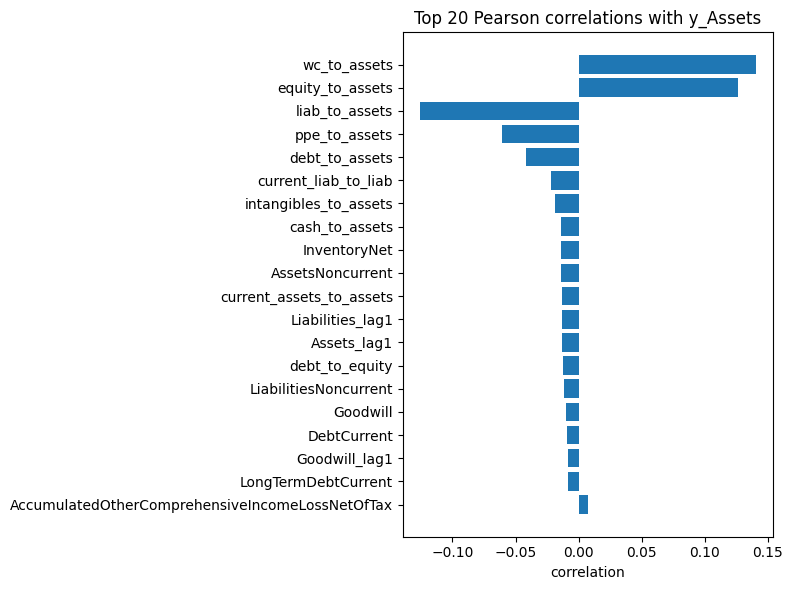

In [5]:
top_n = 20
top_corr = corr_df.head(top_n).iloc[::-1]

plt.figure(figsize=(8, 6))
plt.barh(top_corr["feature"], top_corr["pearson_corr"])
plt.title(f"Top {top_n} Pearson correlations with y_Assets")
plt.xlabel("correlation")
plt.tight_layout()
plt.show()


In [6]:
ratio_summary = []

for col in base_ratios:
    s = df[col]
    ratio_summary.append({
        "feature": col,
        "null_share": s.isna().mean(),
        "mean": s.mean(),
        "std": s.std(),
        "p1": s.quantile(0.01),
        "p50": s.quantile(0.50),
        "p99": s.quantile(0.99),
        "min": s.min(),
        "max": s.max(),
    })

ratio_summary = pd.DataFrame(ratio_summary)
display(ratio_summary)


,feature,null_share,mean,std,p1,p50,p99,min,max
0,cash_to_assets,0.301495,0.176258,0.362770,0.000000,0.067632,1.000000,-20.000000,20.0
1,current_assets_to_assets,0.304637,0.491962,0.373825,0.000780,0.464507,1.000000,-4.271378,20.0
2,liab_to_assets,0.084492,2.644929,5.389196,0.000886,0.712790,20.000000,-20.000000,20.0
3,equity_to_assets,0.084492,-1.746171,5.613256,-20.000000,0.247240,0.999506,-20.000000,20.0
4,current_liab_to_liab,0.314199,0.640364,0.494073,0.029305,0.674713,1.000000,-14.594898,20.0
5,ppe_to_assets,0.388178,0.203821,0.310623,0.000024,0.096852,0.953926,-0.963444,20.0
6,goodwill_to_assets,0.645319,0.172152,0.253674,0.000000,0.115830,0.725645,-1.002840,20.0
7,intangibles_to_assets,0.726393,0.129900,0.303367,0.000071,0.063786,0.914692,-3.842277,20.0
8,wc_to_assets,0.328006,-1.917322,5.425723,-20.000000,0.042614,0.925082,-20.000000,20.0
9,debt_to_assets,0.030052,0.178962,1.253293,0.000000,0.000000,2.311025,-20.000000,20.0


Key observations

Top correlations are ratios, not raw levels or lags

Strongest signals:

wc_to_assets (+0.14)

equity_to_assets (+0.13)

liab_to_assets (−0.13)

Raw balance sheet levels and lags have near-zero linear correlation

Interpretation

Target is structural, not scale-driven

Ratios capture meaningful variation; levels mostly don’t

Low correlations are expected given bounded, noisy target

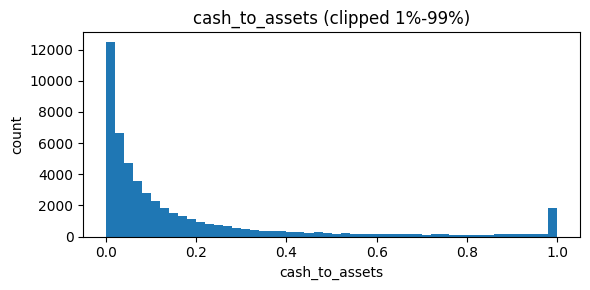

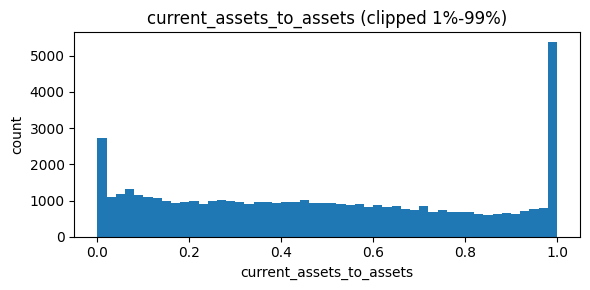

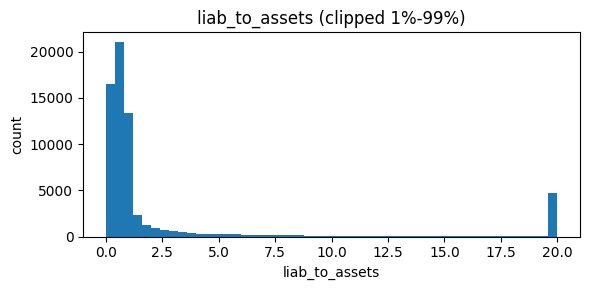

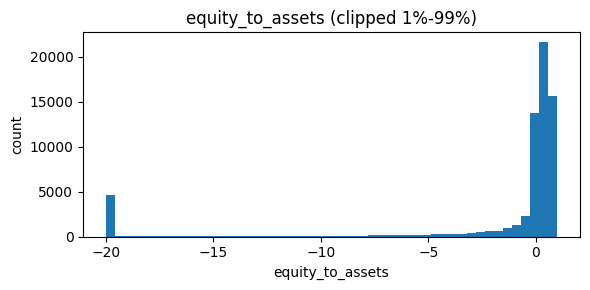

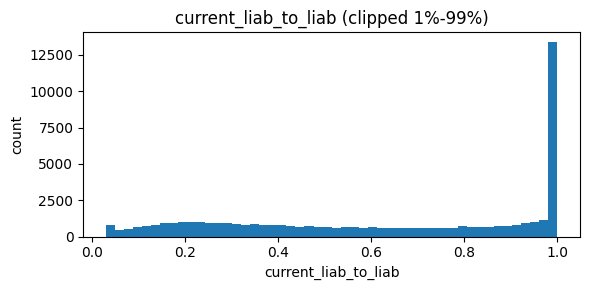

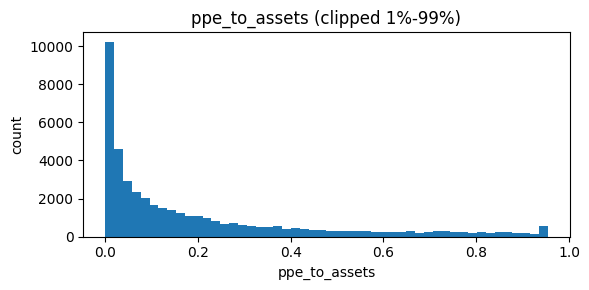

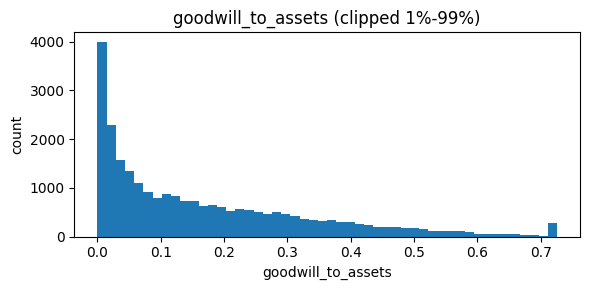

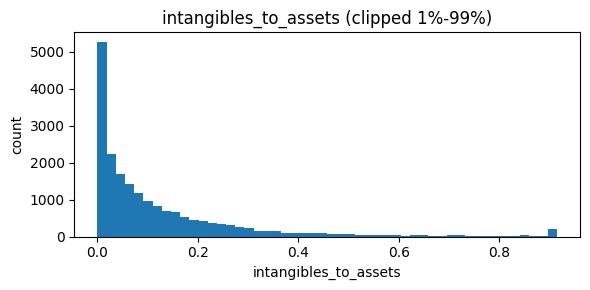

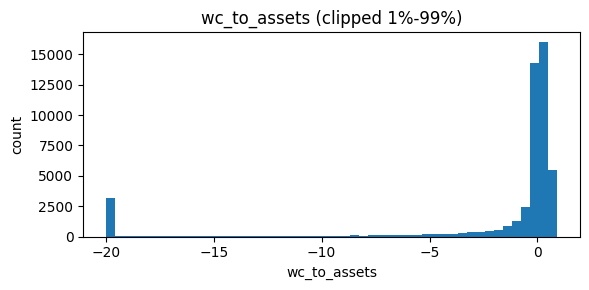

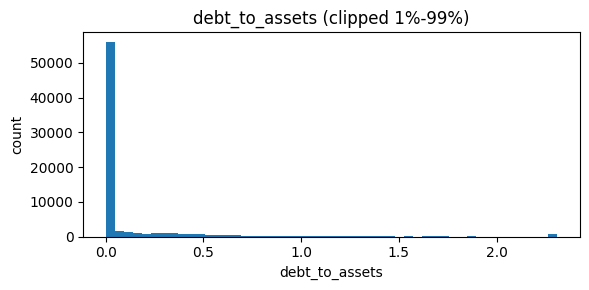

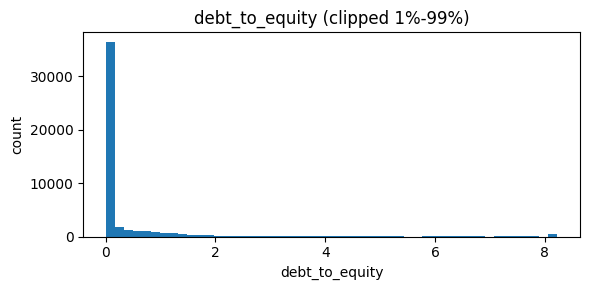

In [7]:
for col in base_ratios:
    s = df[col].dropna()
    if len(s) < 100:
        continue

    lo, hi = s.quantile([0.01, 0.99])
    s_clip = s.clip(lo, hi)

    plt.figure(figsize=(6, 3))
    plt.hist(s_clip, bins=50)
    plt.title(f"{col} (clipped 1%-99%)")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()


Overall

All ratios are bounded, interpretable, and non-pathological

Heavy skew is expected for balance sheet ratios

1%–99% clipping is appropriate

Per-ratio notes (concise)

cash_to_assets, ppe_to_assets, goodwill_to_assets, intangibles_to_assets
→ Right-skewed, long tails, economically sensible

current_assets_to_assets, current_liab_to_liab
→ Broad support in 
[
0
,
1
]
[0,1], many firms near extremes → informative

liab_to_assets, equity_to_assets, wc_to_assets
→ Can exceed 
[
0
,
1
]
[0,1] or go negative → expected with negative equity / WC
→ Strong signal carriers (confirmed by correlations)

debt_to_assets
→ Mass near 0, sparse high values → leverage indicator, keep

No red flags

No explosions

No undefined regions dominating

In [8]:
top_features = corr_df.head(30)["feature"].tolist()

corr_matrix = (
    df[top_features]
    .corr()
)

# Identify highly correlated pairs
pairs = []
cols = corr_matrix.columns

for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        c = corr_matrix.iloc[i, j]
        if abs(c) > 0.98:
            pairs.append((cols[i], cols[j], c))

high_corr_pairs = pd.DataFrame(
    pairs, columns=["feature_1", "feature_2", "corr"]
)

display(high_corr_pairs)


,feature_1,feature_2,corr
0,equity_to_assets,liab_to_assets,-0.991610
1,Liabilities_lag1,Assets_lag1,0.997705
2,Goodwill,Goodwill_lag1,0.984005
3,PrepaidExpenseCurrent_lag1,PrepaidExpenseCurrent,0.985246
4,StockholdersEquity_lag1,StockholdersEquity,0.993077


What we see

Structural identities (expected):

equity_to_assets ↔ liab_to_assets (≈ −1)

Lag ↔ current levels (Assets, Liabilities, Equity)

Pure persistence:

Goodwill ↔ Goodwill_lag1

PrepaidExpenseCurrent ↔ lag

Interpretation

These are not bugs — they reflect accounting identities and persistence

Redundancy is mostly within levels vs lags, not ratios

Decisions

⚠️ Do not include both sides of an identity for linear models

✅ Tree/GBM models can tolerate this

Optional pruning (later):

keep either liab_to_assets or equity_to_assets (not both)

prefer lagged levels over current if needed for causality

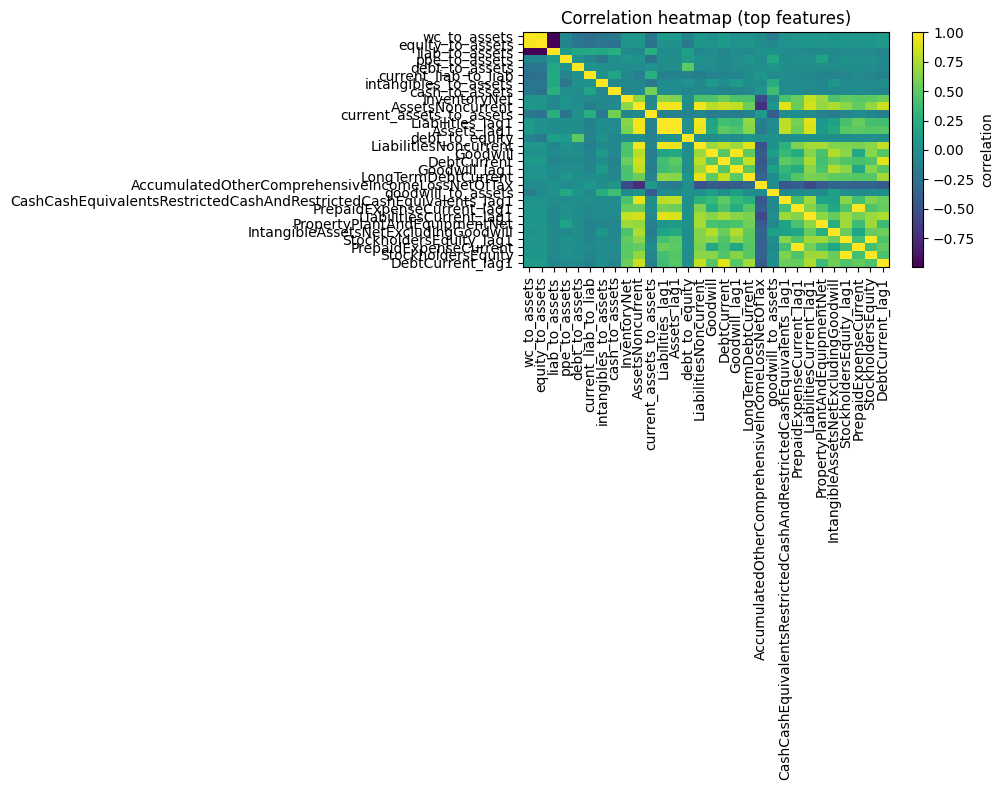

In [9]:
plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="correlation")
plt.xticks(range(len(top_features)), top_features, rotation=90)
plt.yticks(range(len(top_features)), top_features)
plt.title("Correlation heatmap (top features)")
plt.tight_layout()
plt.show()


What the heatmap shows

Clear blocks of high correlation among:

balance-sheet levels

their lagged versions

Ratios form a separate, weakly correlated cluster

Interpretation

Multicollinearity is localized and structural

No widespread cross-feature leakage

Confirms:

levels ↔ levels (expected)

lags ↔ current (expected)

ratios ≈ orthogonal signal

In [10]:
ratio_corrs = corr_df[corr_df["feature"].isin(base_ratios)]
lag_corrs = corr_df[corr_df["feature"].isin(lag_features)]

print("Top ratio correlations:")
display(ratio_corrs.head(10))

print("Top lag correlations:")
display(lag_corrs.head(10))


Top ratio correlations:


,feature,pearson_corr,abs_corr
58,wc_to_assets,0.140511,0.140511
53,equity_to_assets,0.126640,0.126640
52,liab_to_assets,-0.125979,0.125979
55,ppe_to_assets,-0.060834,0.060834
59,debt_to_assets,-0.041489,0.041489
54,current_liab_to_liab,-0.021970,0.021970
57,intangibles_to_assets,-0.018440,0.018440
50,cash_to_assets,-0.014235,0.014235
51,current_assets_to_assets,-0.013483,0.013483
60,debt_to_equity,-0.012758,0.012758


Top lag correlations:


,feature,pearson_corr,abs_corr
28,Liabilities_lag1,-0.013233,0.013233
25,Assets_lag1,-0.012909,0.012909
39,Goodwill_lag1,-0.008530,0.008530
34,CashCashEquivalentsRestrictedCashAndRestricted...,0.004970,0.004970
37,PrepaidExpenseCurrent_lag1,0.004881,0.004881
29,LiabilitiesCurrent_lag1,-0.004539,0.004539
31,StockholdersEquity_lag1,-0.003991,0.003991
41,DebtCurrent_lag1,-0.003158,0.003158
48,AdditionalPaidInCapital_lag1,-0.003094,0.003094
40,IntangibleAssetsNetExcludingGoodwill_lag1,-0.002932,0.002932


Notebook 03 — Cell 9 (Ratios vs lags)

What this shows

Ratios dominate linear signal

Top ratio corr ≈ 0.14

Several ratios in top 10

Lagged levels are weak

Top lag corr ≈ 0.013

Near-zero linear relationship

Interpretation

Confirms earlier finding:

Target is structural, not scale-driven

Ratios capture cross-sectional differences

Lagged levels may still help non-linearly (trees, interactions)

In [11]:
summary = corr_df.copy()

summary["group"] = np.where(
    summary["feature"].isin(base_ratios), "ratio",
    np.where(summary["feature"].isin(lag_features), "lag", "other")
)

display(
    summary.groupby("group")
    .agg(
        n_features=("feature", "count"),
        mean_abs_corr=("abs_corr", "mean"),
        max_abs_corr=("abs_corr", "max"),
    )
)


,n_features,mean_abs_corr,max_abs_corr
group,,,
lag,25,0.003292,0.013233
other,25,0.004255,0.014192
ratio,11,0.052865,0.140511


Key numbers

Ratios (11):

Mean |corr| ≈ 0.053

Max |corr| ≈ 0.14

Lags (25):

Mean |corr| ≈ 0.003

Other levels (25):

Mean |corr| ≈ 0.004

Interpretation

Ratios are ~15× more informative linearly than lags or levels

Lags and levels add context, not direct signal

Pattern is clean and consistent with earlier EDA

Final decisions from Notebook 03

✅ Keep all ratio features

✅ Keep lags for nonlinear models

❌ Do not rely on linear correlation for pruning

⚠️ If using linear models later:

drop one of (equity_to_assets, liab_to_assets)

reduce level–lag duplication